In [3]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt
import glob
import numpy as np
import jax.numpy as jnp
import utils_plotting

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Phase 1: Calibrate climate sensitivity via prescribed CO2 concentrations -> $\Delta T$

In [4]:
conc_path = '/Users/chriswomack/Documents/PhD/Project 2/data/MESM/conc_driven'
conc_1pct_path = f'{conc_path}/1PRCO2/'

In [5]:
def calculate_ensemble_average(file_pattern):
    # Find all files matching the string pattern (e.g., 'dt2m_ascii_*.txt')
    file_list = glob.glob(file_pattern)

    if not file_list:
        print("No files found matching the pattern.")
        return None

    all_data = []

    for file in file_list:
        # Load the data; np.loadtxt handles the whitespace formatting automatically
        # usecols=(1,) extracts the values from the 2nd column in the text file
        # (which corresponds to your data values like -0.036, 0.064, etc.)
        data = np.loadtxt(file, usecols=(1,))
        all_data.append(data)

    # Stack the list into a 2D array: (number_of_members, number_of_timesteps)
    ensemble_stack = np.stack(all_data)

    # Take the mean across the ensemble members (axis 0)
    ensemble_average = np.mean(ensemble_stack, axis=0)

    return ensemble_average

In [6]:
avg_1pct = calculate_ensemble_average(conc_1pct_path + 'dt2m_ascii_*.txt')
target_dict = {'1pctCO2': avg_1pct}

In [7]:
n_years_1pct = len(avg_1pct)

base_co2 = 286.4
co2_1pct = base_co2 * (1.01 **  np.arange(n_years_1pct))
conc_mat_1pct = jnp.zeros((3, len(co2_1pct)))
conc_mat_1pct = conc_mat_1pct.at[0,:].set(co2_1pct)
conc_mat_1pct = conc_mat_1pct.at[1,:].set(720.0)
conc_mat_1pct = conc_mat_1pct.at[2,:].set(270.0)

conc_dict = {'1pctCO2': conc_mat_1pct}
emis_dict = {'1pctCO2': jnp.zeros((5, len(co2_1pct)))}

Starting Climate Sensitivity Calibration (Conc -> Temp)...
Step 0 | Loss (Temp MSE): 0.0734
Step 100 | Loss (Temp MSE): 0.0024
Step 200 | Loss (Temp MSE): 0.0016
Step 300 | Loss (Temp MSE): 0.0014
Step 400 | Loss (Temp MSE): 0.0013
Step 500 | Loss (Temp MSE): 0.0013
Step 600 | Loss (Temp MSE): 0.0012
Step 700 | Loss (Temp MSE): 0.0011
Step 800 | Loss (Temp MSE): 0.0010
Step 900 | Loss (Temp MSE): 0.0010
Step 999 | Loss (Temp MSE): 0.0009


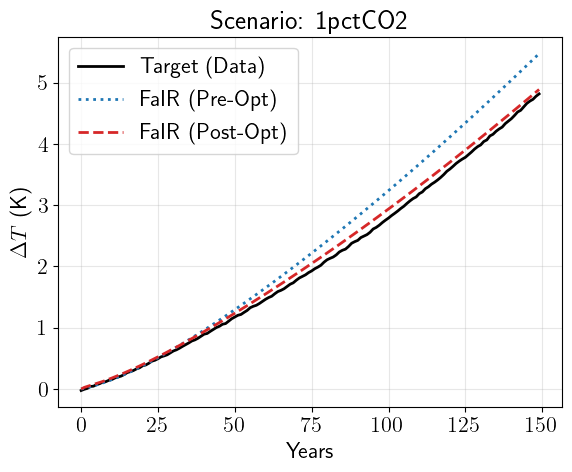

In [11]:
filepath = 'data/JAX_calibration/calib_MESM_CO2_only.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')
n_steps = 1000
dt = 0.1
theta_opt, theta_opt_dict = utils_FaIR_JAX.calibrate_climate_sensitivity(filepath, emis_dict, conc_dict, target_dict, theta0, dt, n_steps, learning_rate=1e-2)
utils_plotting.plot_calibration_results(conc_dict, emis_dict, target_dict, theta0, theta_opt, dt=0.1)

### Phase 2: Calibrate carbon cycle via emissions -> concentrations

In [14]:
emis_path = '/Users/chriswomack/Documents/PhD/Project 2/data/MESM/emis_driven'
emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'

emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = jnp.zeros((5, len(emis_1pct)))
emis_mat_1pct = emis_mat_1pct.at[0,:].set(emis_1pct)
emis_dict = {'1pctCO2': emis_mat_1pct}
target_conc_dict = {'1pctCO2': conc_mat_1pct}

Starting Carbon Cycle Calibration (Emis -> Conc)...
Step 0 | Loss (Conc MSE): 380.2673
Step 100 | Loss (Conc MSE): 52.0457
Step 199 | Loss (Conc MSE): 43.5821


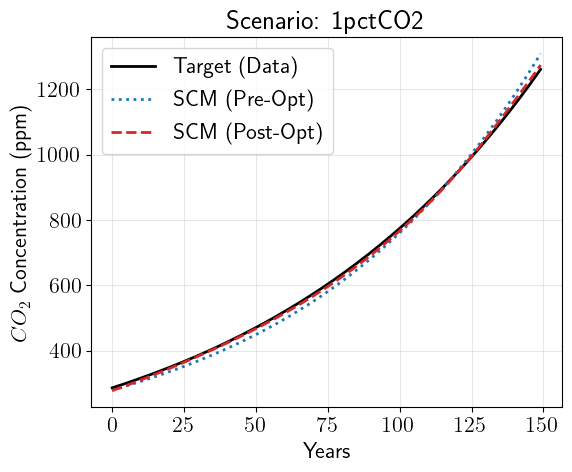

In [27]:
filepath = 'data/JAX_calibration/calib_MESM_emis_to_conc.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')
n_steps = 200
dt = 0.1
theta_opt_emis, theta_opt_dict_emis = utils_FaIR_JAX.calibrate_carbon_cycle(filepath, emis_dict, target_conc_dict, theta0, dt, n_steps, learning_rate=1e-2, mode='FaIR')
utils_plotting.plot_calibration_results(None, emis_dict, target_conc_dict, theta0, theta_opt_emis, dt=0.1, calib='Carbon')

### Phase 3: emissions to temperature (verification)

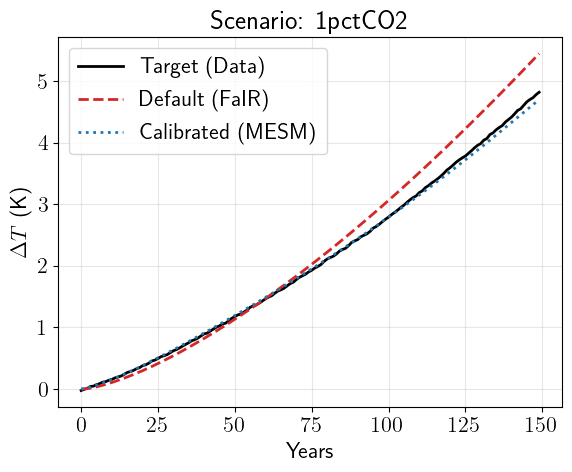

In [29]:
utils_plotting.plot_model_comparison(emis_dict, {'1pctCO2': target_dict['1pctCO2']}, theta0, mode='MESM', dt=0.1)